# Tech Challenge - Modelo de previsão de tendência da ibovespa.

No notebook abaixo, fizemos um estudo em relação aos modelos de machine learning mais apropriados para previsão da tendência dos dados da ibovespa. Vejamos abaixo como tudo isso foi feito:

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier

Para importar os dados do mercado financeiro de forma mais facilitada, utilizaremos a biblioteca do yahoo finance. As outras são bibliotecas padrão do python para análise de dados, assim como o sklearn para cuidar da parte lógica dos modelos.

In [ ]:
df = yf.download(
    "^BVSP",
    start=(datetime.today() - timedelta(days=365*2)).strftime("%Y-%m-%d"),
    end=datetime.today().strftime("%Y-%m-%d")
)

/tmp/ipython-input-2432812880.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Verificando se a importação deu certo
df.head()

Price,Close,High,Low,Open,Volume
Ticker,^BVSP,^BVSP,^BVSP,^BVSP,^BVSP
Date,,,,,
2024-01-10,130841.0,131628.0,130438.0,131447.0,8958400
2024-01-11,130649.0,131308.0,129898.0,130841.0,9761700
2024-01-12,130988.0,131927.0,130410.0,130652.0,10661900
2024-01-15,131521.0,131606.0,130253.0,130988.0,5746600
2024-01-16,129294.0,131517.0,129147.0,131515.0,11911300


In [ ]:
# Verificando se há dados nulos
df.isnull().sum()

,,0
Price,Ticker,
Close,^BVSP,0
High,^BVSP,0
Low,^BVSP,0
Open,^BVSP,0
Volume,^BVSP,0


As vezes, a biblioteca Yahoo Finance retorna dados com o mesmo index. A linha abaixo lida com esse tipo de inconsistência.

In [ ]:
# Remove MultiIndex se existir
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

Feita a nossa exploração inicial, vamos preparar a base para a previsão, a começar pela criação da nossa variável chave: a tendência.

In [ ]:
# Calculando nossa variável chave
df["next_close"] = df["Close"].shift(-1)
df["trend"] = (df["next_close"] > df["Close"]).astype(int)

Feita a definição da nossa variável chave, vamos adicionar algumas outras variáveis para que o nosso modelo preveja melhor os próximos dias. São elas:

- O retorno dos próximos 1, 3 e dos próximos 5 dias.

- A volatilidade dos retornos nos últimos 5 e 10 dias.

Todas elas servem para ajudar o modelo a prever melhor a tendência que virá.

In [ ]:
df["ret_1"] = df["Close"].pct_change()
df["ret_3"] = df["Close"].pct_change(3)
df["ret_5"] = df["Close"].pct_change(5)

df["vol_5"] = df["ret_1"].rolling(5).std()
df["vol_10"] = df["ret_1"].rolling(10).std()

In [ ]:
# Fazemos uma limpeza final dos dados
df = df.dropna()

Agora iniciando na parte de treinamento do modelo, tiramos a parte de tendência e treinamento do modelo das variáveis de X pois elas que serão usadas no Y (Como trend é feito a partir de next_close, tiramos ela para que não haja vazamento de dados)

Nós também tiramos Close, High, Low e End pois elas não agregam com o que queremos prever.

In [ ]:
features = ["ret_1", "ret_3", "ret_5", "vol_5", "vol_10", "Volume"]
X = df[features]

y = df["trend"]


Realizamos a separação do conjunto de testes manualmente para que não haja embaralhamento.

In [ ]:
X_train = X.iloc[:-30]
X_test = X.iloc[-30:]
y_train = y.iloc[:-30]
y_test = y.iloc[-30:]

Realizamos então o escalamento dos dados:

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


E como vamos usar o KNN, é importante também que averiguemos qual a melhor quantidade de k para o mesmo. Já que este é indicador chave do sucesso do modelo.

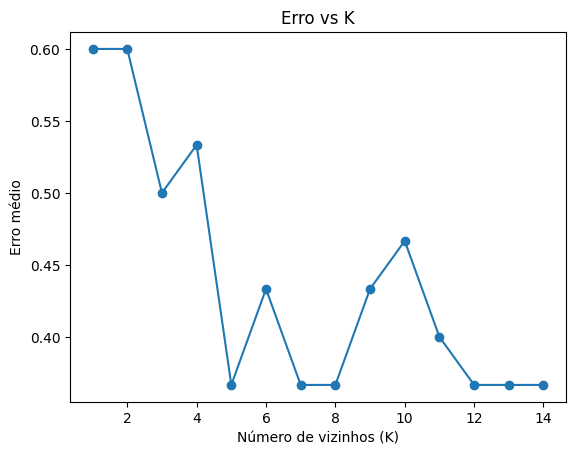

In [ ]:
error = []

# Calculando erro para K entre 1 e 14
for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i, weights="distance")
    knn.fit(X_train_scaled, y_train)

    pred_i = knn.predict(X_test_scaled)
    error.append(np.mean(pred_i != y_test))

plt.plot(range(1, 15), error, marker='o')
plt.xlabel('Número de vizinhos (K)')
plt.ylabel('Erro médio')
plt.title('Erro vs K')
plt.show()


Agora testamos com cada um dos modelos. Como estamos usando o KFold para testar vários modelos ao mesmo tempo, para que não haja vazeamento de dados, escalamos os dados dentro do loop do kfold.

Para testar, selecionamos 5 tipos de modelo:

Logistic Regression: A Regressão Logística permite avaliar se o conjunto de features construídas contém informação preditiva real, antes de recorrer a modelos mais complexos.

XGBoost: Modelo robusto altamente utilziado em fundos quantitativos. Lida bem com overfitting, sinais fracos e interações complexas.

KNN: O KNN permite investigar se o mercado tende a repetir comportamentos quando condições técnicas semelhantes ocorrem, uma hipótese comum em análise técnica.

Random Forest: O Random Forest representa um equilíbrio entre desempenho e estabilidade, sendo amplamente utilizado como benchmark em problemas financeiros.

SVM: Lida bem com margens pequenas e dados ruidosos, mas foi adicionado aqui apenas para dar melhor embasamento ao estudo.

In [ ]:
# Fazendo dicionário de modelos
models = {
    "KNN": KNeighborsClassifier(
        n_neighbors=13,
        weights="distance"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ),

    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}


In [ ]:
results = []

for name, model in models.items():

    # Modelos que precisam de dados escalados
    if name in ["KNN", "Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    # F1 por classe
    f1_class_0 = f1_score(y_test, y_pred, pos_label=0)
    f1_class_1 = f1_score(y_test, y_pred, pos_label=1)

    results.append({
        "Modelo": name,
        "Acurácia": acc,
        "F1_Queda (0)": f1_class_0,
        "F1_Alta (1)": f1_class_1
    })

    print(f"\n===== {name} =====")
    print(f"Acurácia: {acc:.3f}")
    print(f"F1 - Queda (0): {f1_class_0:.3f}")
    print(f"F1 - Alta  (1): {f1_class_1:.3f}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))



===== KNN =====
Acurácia: 0.633
F1 - Queda (0): 0.421
F1 - Alta  (1): 0.732

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.44      0.40      0.42        10
           1       0.71      0.75      0.73        20

    accuracy                           0.63        30
   macro avg       0.58      0.57      0.58        30
weighted avg       0.62      0.63      0.63        30


===== Random Forest =====
Acurácia: 0.467
F1 - Queda (0): 0.385
F1 - Alta  (1): 0.529

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.31      0.50      0.38        10
           1       0.64      0.45      0.53        20

    accuracy                           0.47        30
   macro avg       0.48      0.47      0.46        30
weighted avg       0.53      0.47      0.48        30


===== Logistic Regression =====
Acurácia: 0.667
F1 - Queda (0): 0.500
F1 - Alta  (1): 0.750

Relatório de Classificação:
  

In [ ]:
# Exibindo resultados
df_results = pd.DataFrame(results).sort_values(by="Acurácia", ascending=False)
df_results

,Modelo,Acurácia,F1_Queda (0),F1_Alta (1)
2,Logistic Regression,0.666667,0.500000,0.750000
0,KNN,0.633333,0.421053,0.731707
3,SVM,0.566667,0.315789,0.682927
1,Random Forest,0.466667,0.384615,0.529412
4,XGBoost,0.366667,0.173913,0.486486


Como pode ser verificado acima, o Logistic Regression obtem o melhor resultado entre eles, tanto no balanceamento das classes, tanto na acurácia. Porém, existe mais uma métrica importante de analisarmos: a curva ROC. É ela que nos dirá a capacidade discriminatória dos 2 modelos.

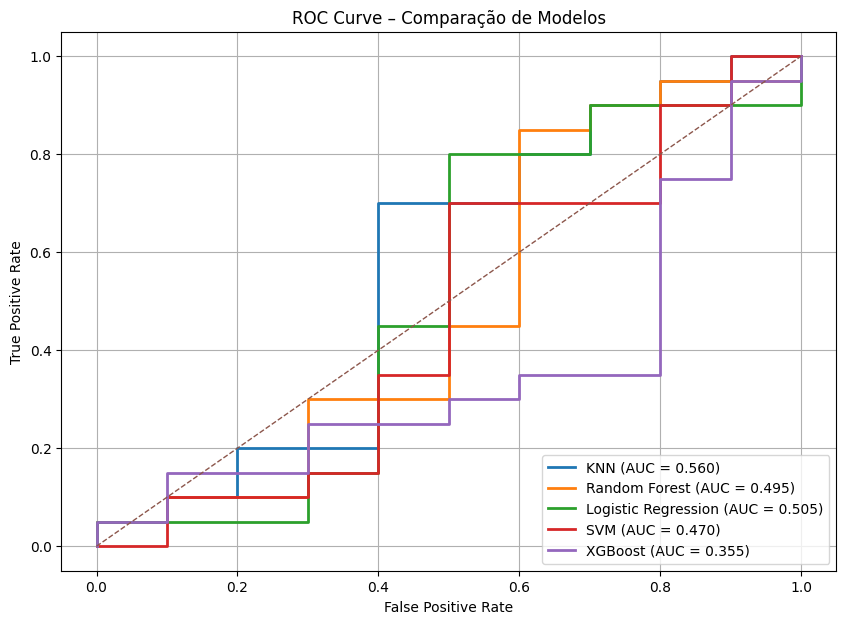

In [ ]:
plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Modelos que precisam de dados escalados
    if name in ["KNN", "Logistic Regression", "SVM"]:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    model.fit(X_tr, y_train)

    # Probabilidades
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        # Para SVM sem predict_proba
        y_score = model.decision_function(X_te)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Linha aleatória
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Comparação de Modelos")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Com base então no gráfico acima, apesar da regressão logística apresentar maior acurácia no threshold padrão, seu AUC próximo de 0.5 indica baixa capacidade discriminatória. O KNN, com AUC superior, demonstra melhor habilidade de separação entre dias de alta e queda, sendo um modelo mais promissor após calibração do threshold. Vamos testar essa hipótese:

Para ela: vamos usar 2 tresholds: um de 0.4 (que deixa os modelos com predições mais agressivas), e um de 0.6 (que deixa os modelos mais conservadores)

In [ ]:
thresholds = np.arange(0.40, 0.61, 0.02)
results = []

threshold_results = []

for name, model in models.items():

    # Seleciona dados
    if name in ["KNN", "Logistic Regression", "SVM"]:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    model.fit(X_tr, y_train)

    # Score contínuo
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)

    for t in thresholds:
        y_pred_t = (y_score > t).astype(int)

        acc_t = accuracy_score(y_test, y_pred_t)

        threshold_results.append({
            "Modelo": name,
            "Threshold": t,
            "Acurácia": acc_t
        })


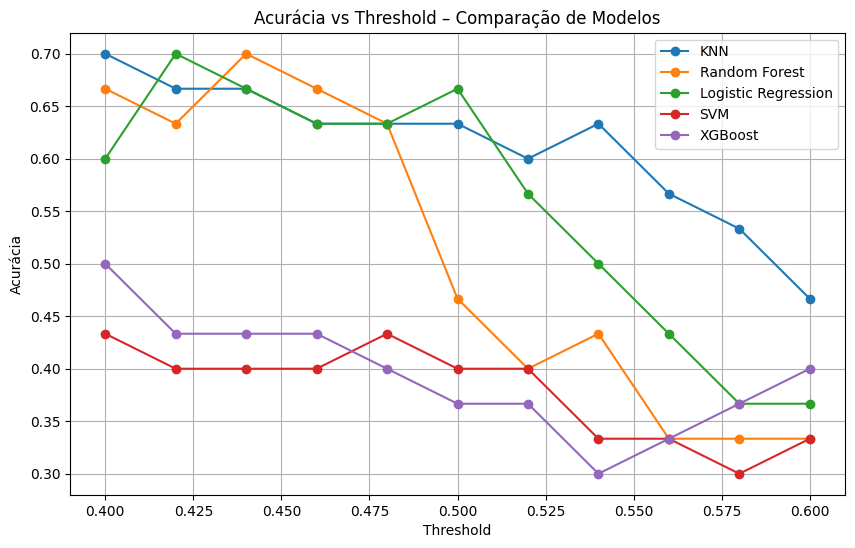

In [ ]:
df_thr = pd.DataFrame(threshold_results)
plt.figure(figsize=(10, 6))

for name in df_thr["Modelo"].unique():
    df_plot = df_thr[df_thr["Modelo"] == name]
    plt.plot(
        df_plot["Threshold"],
        df_plot["Acurácia"],
        marker="o",
        label=name
    )

plt.xlabel("Threshold")
plt.ylabel("Acurácia")
plt.title("Acurácia vs Threshold – Comparação de Modelos")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Exibindo resultados
df_results = df_thr.sort_values(by="Acurácia", ascending=False)
df_results

,Modelo,Threshold,Acurácia
0,KNN,0.40,0.700000
13,Random Forest,0.44,0.700000
23,Logistic Regression,0.42,0.700000
11,Random Forest,0.40,0.666667
14,Random Forest,0.46,0.666667
2,KNN,0.44,0.666667
1,KNN,0.42,0.666667
24,Logistic Regression,0.44,0.666667
27,Logistic Regression,0.50,0.666667
12,Random Forest,0.42,0.633333


Como é possível de se verificar nos gráficos acima, caso avaliemos de um treshold mais agressivo, o KNN se destaca com uma capacidade preditiva de 70. Além disso, quanto mais conservador o modelo vai se tornando, mais o logistic regression se destaca, chegando a até 70% de acurácia e, caso sejamos extremamente conservadores, podemos chegar até 50% de acurácia com o KNN de treshold de 60%.

Para finalizar,tendo o treshold em mãos, vamos fazer uma análise temporal de forma a verificar quantos anos de dados impactam na acurácia do modelo.

In [ ]:
# =========================================================
# ANÁLISE TEMPORAL – ACURÁCIA VS JANELA DE TREINAMENTO
# (ALINHADA COM A ANÁLISE DE THRESHOLD)
# =========================================================

anos_treinamento = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
threshold_temporal = 0.40

temporal_results = []

for anos in anos_treinamento:

    df_temp = yf.download(
        "^BVSP",
        start=(datetime.today() - timedelta(days=365 * anos)).strftime("%Y-%m-%d"),
        end=datetime.today().strftime("%Y-%m-%d")
    )

    if isinstance(df_temp.columns, pd.MultiIndex):
        df_temp.columns = df_temp.columns.get_level_values(0)

    # Engenharia de variáveis (mesma do modelo original)
    df_temp["next_close"] = df_temp["Close"].shift(-1)
    df_temp["trend"] = (df_temp["next_close"] > df_temp["Close"]).astype(int)

    df_temp["ret_1"] = df_temp["Close"].pct_change()
    df_temp["ret_3"] = df_temp["Close"].pct_change(3)
    df_temp["ret_5"] = df_temp["Close"].pct_change(5)

    df_temp["vol_5"] = df_temp["ret_1"].rolling(5).std()
    df_temp["vol_10"] = df_temp["ret_1"].rolling(10).std()

    df_temp = df_temp.dropna()

    X_temp = df_temp[features]
    y_temp = df_temp["trend"]

    # Split temporal fixo (últimos 30 dias)
    X_train = X_temp.iloc[:-30]
    X_test  = X_temp.iloc[-30:]
    y_train = y_temp.iloc[:-30]
    y_test  = y_temp.iloc[-30:]

    # Escalonamento
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    for name, model in models.items():

        # Escolha correta dos dados
        if name in ["KNN", "Logistic Regression", "SVM"]:
            X_tr = X_train_scaled
            X_te = X_test_scaled
        else:
            X_tr = X_train
            X_te = X_test

        model.fit(X_tr, y_train)

        # Score contínuo (igual ao primeiro bloco)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_te)[:, 1]
        else:
            y_score = model.decision_function(X_te)

        # Aplicação do mesmo threshold
        y_pred = (y_score > threshold_temporal).astype(int)

        acc = accuracy_score(y_test, y_pred)
        # F1 por classe
        f1_class_0 = f1_score(y_test, y_pred, pos_label=0)
        f1_class_1 = f1_score(y_test, y_pred, pos_label=1)

        # AUC (usa score contínuo, sem threshold)
        auc = roc_auc_score(y_test, y_score)

        temporal_results.append({
            "Modelo": name,
            "Anos_Treinamento": anos,
            "Acurácia": acc,
            "AUC": auc,
            "F1 Classe  0": f1_class_0,
            "F1 Classe  1": f1_class_1,
        })

# DataFrame final
df_temporal = pd.DataFrame(temporal_results)

/tmp/ipython-input-1889867139.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1889867139.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1889867139.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1889867139.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1889867139.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************10

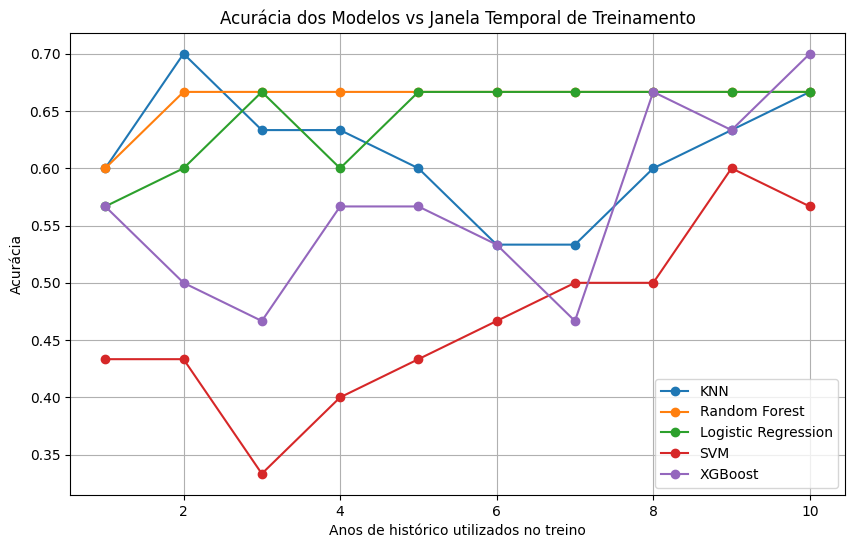

In [ ]:


# =========================================================
# GRÁFICO: ACURÁCIA VS ANOS DE TREINAMENTO
# =========================================================

plt.figure(figsize=(10, 6))

for model in df_temporal["Modelo"].unique():
    df_plot = df_temporal[df_temporal["Modelo"] == model]
    plt.plot(
        df_plot["Anos_Treinamento"],
        df_plot["Acurácia"],
        marker="o",
        label=model
    )

plt.xlabel("Anos de histórico utilizados no treino")
plt.ylabel("Acurácia")
plt.title("Acurácia dos Modelos vs Janela Temporal de Treinamento")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
df_temporal.sort_values(by="Acurácia", ascending=False).head(10)

,Modelo,Anos_Treinamento,Acurácia,AUC,F1 Classe 0,F1 Classe 1
5,KNN,2,0.700000,0.560,0.400,0.800000
49,XGBoost,10,0.700000,0.475,0.400,0.800000
16,Random Forest,4,0.666667,0.450,0.000,0.800000
11,Random Forest,3,0.666667,0.435,0.000,0.800000
12,Logistic Regression,3,0.666667,0.400,0.000,0.800000
36,Random Forest,8,0.666667,0.395,0.000,0.800000
45,KNN,10,0.666667,0.465,0.375,0.772727
46,Random Forest,10,0.666667,0.485,0.000,0.800000
42,Logistic Regression,9,0.666667,0.685,0.000,0.800000
39,XGBoost,8,0.666667,0.450,0.375,0.772727


In [ ]:
df_temporal.sort_values(by="AUC", ascending=False).head(10)

,Modelo,Anos_Treinamento,Acurácia,AUC,F1 Classe 0,F1 Classe 1
47,Logistic Regression,10,0.666667,0.705,0.000000,0.800000
42,Logistic Regression,9,0.666667,0.685,0.000000,0.800000
48,SVM,10,0.566667,0.650,0.480000,0.628571
43,SVM,9,0.600000,0.630,0.571429,0.625000
37,Logistic Regression,8,0.666667,0.615,0.000000,0.800000
33,SVM,7,0.500000,0.615,0.516129,0.482759
32,Logistic Regression,7,0.666667,0.610,0.000000,0.800000
38,SVM,8,0.500000,0.610,0.516129,0.482759
23,SVM,5,0.433333,0.595,0.514286,0.320000
19,XGBoost,4,0.566667,0.590,0.434783,0.648649


Quando comparamos em uma questão de tempo, o KNN com 2 anos e 0.4 de threshold ainda se destaca como modelo que tem a maior acurácia mas, no quesito distinção entre as classes, o SVM com 9 anos de dados apresenta um resultado mais interessante. Por mais que sua acurácia não esteja tão alta assim, ele tem um melhor balanceamento entre as classes e consegue generalizar melhor do que o KNN. O logistic regression, por mais que está obtendo uma AUC alta, está ignorando completamente a classe 0, o que o torna inoperável para o dia dia mas o torna bom para ver se o mercado está favorável ou não. Ele está negligenciando completamente a classe 0 porque o nosso treshold está como 40%, o que faz com que ele seja mais agressivo e, consequentemente, fale que todo dia vai subir.

Portanto, como conclusão final do trabalho, os melhores modelos para se usar seriam:

1º - Logistic regression com 10 anos de treinamento para verificar se o mercado está favorável

2º - SVM para definir a direção diária

E para deixar tudo resumido finalizando o trabalho, segue abaixo um dataframe com os resultados de todos os testes com todos os períodos e thresholds estudados.

Muito obrigado :)

In [ ]:
# =========================================================
# GRID FINAL – MODELOS x ANOS DE TREINAMENTO x THRESHOLD
# =========================================================

anos_treinamento = range(1, 11)
thresholds_grid = np.arange(0.4, 0.61, 0.2)

grid_results = []

for anos in anos_treinamento:

    df_temp = yf.download(
        "^BVSP",
        start=(datetime.today() - timedelta(days=365 * anos)).strftime("%Y-%m-%d"),
        end=datetime.today().strftime("%Y-%m-%d")
    )

    if isinstance(df_temp.columns, pd.MultiIndex):
        df_temp.columns = df_temp.columns.get_level_values(0)

    # Engenharia de variáveis (mesma lógica do modelo base)
    df_temp["next_close"] = df_temp["Close"].shift(-1)
    df_temp["trend"] = (df_temp["next_close"] > df_temp["Close"]).astype(int)

    df_temp["ret_1"] = df_temp["Close"].pct_change()
    df_temp["ret_3"] = df_temp["Close"].pct_change(3)
    df_temp["ret_5"] = df_temp["Close"].pct_change(5)

    df_temp["vol_5"] = df_temp["ret_1"].rolling(5).std()
    df_temp["vol_10"] = df_temp["ret_1"].rolling(10).std()

    df_temp = df_temp.dropna()

    X_temp = df_temp[features]
    y_temp = df_temp["trend"]

    # Split temporal fixo
    X_train = X_temp.iloc[:-30]
    X_test  = X_temp.iloc[-30:]
    y_train = y_temp.iloc[:-30]
    y_test  = y_temp.iloc[-30:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    for name, model in models.items():

        if name in ["KNN", "Logistic Regression", "SVM"]:
            X_tr = X_train_scaled
            X_te = X_test_scaled
        else:
            X_tr = X_train
            X_te = X_test

        model.fit(X_tr, y_train)

        # Score contínuo
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_te)[:, 1]
        else:
            y_score = model.decision_function(X_te)

        for t in thresholds_grid:
            y_pred = (y_score > t).astype(int)

            grid_results.append({
                "Modelo": name,
                "Anos_Treinamento": anos,
                "Threshold": t,
                "Acurácia": accuracy_score(y_test, y_pred),
                "AUC": roc_auc_score(y_test, y_score),
                "F1_Classe_0": f1_score(y_test, y_pred, pos_label=0),
                "F1_Classe_1": f1_score(y_test, y_pred, pos_label=1)
            })

# DataFrame final
df_grid_final = pd.DataFrame(grid_results)


/tmp/ipython-input-359907023.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-359907023.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-359907023.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-359907023.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-359907023.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(
[*********************100%***

In [ ]:
# Exibição ordenada
df_grid_final.sort_values(
    by=["AUC", "Acurácia"],
    ascending=False
).reset_index(drop=True)

,Modelo,Anos_Treinamento,Threshold,Acurácia,AUC,F1_Classe_0,F1_Classe_1
0,Logistic Regression,10,0.4,0.666667,0.705,0.000000,0.800000
1,Logistic Regression,10,0.6,0.333333,0.705,0.500000,0.000000
2,Logistic Regression,9,0.4,0.666667,0.685,0.000000,0.800000
3,Logistic Regression,9,0.6,0.333333,0.685,0.500000,0.000000
4,SVM,10,0.4,0.566667,0.650,0.480000,0.628571
...,...,...,...,...,...,...,...
95,KNN,4,0.6,0.300000,0.355,0.322581,0.275862
96,KNN,6,0.4,0.533333,0.330,0.125000,0.681818
97,KNN,6,0.6,0.400000,0.330,0.400000,0.400000
98,Logistic Regression,4,0.4,0.600000,0.320,0.000000,0.750000
